In [23]:
import torch
from torch import nn
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms.v2 as T
from torchvision.datasets import ImageFolder

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import random

import flax

import optax

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("running on", device)

running on cuda


In [30]:
data_path = Path(r"C:\Users\bamilosin\Documents\datasets\vision\food vision data\pizza_steak_sushi-10%")

transforms = T.Compose([
    T.ToImage(),
    T.Resize((128,128)),
    T.ToDtype(torch.float)
])

train_dataset = ImageFolder(data_path / "train", transforms)
val_dataset = ImageFolder(data_path / "test", transforms)

## jax collate function
def numpy_collate(batch):
    if isinstance(batch[0], np.ndarray):
        return np.stack(batch)
    elif isinstance(batch[0], (tuple, list)):
        transposed = zip(*batch)
        return [numpy_collate(samples) for samples in transposed]
    else:
        return np.array(batch)

batch_size=64
train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True, collate_fn=numpy_collate)
val_dataloader = DataLoader(val_dataset, batch_size, shuffle=False, collate_fn=numpy_collate)

In [54]:
images, labels = next(iter(train_dataloader))

In [63]:
classes = train_dataset.classes
classes

['pizza', 'steak', 'sushi']

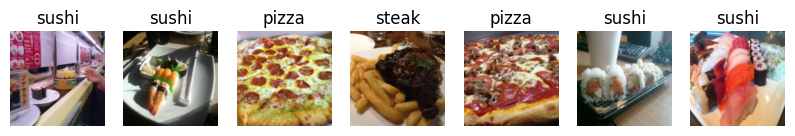

In [69]:
# plot images
samples = torch.randperm(len(images))[:7]

fig, axs = plt.subplots(nrows=1, ncols=7, figsize=(10,5))
for i, sample in enumerate(samples):
    img = images[sample].transpose(1,2,0).astype(np.uint8)
    axs[i].imshow(img)
    axs[i].set_title(classes[labels[sample]])
    axs[i].axis(False)